In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [6]:
df = pd.read_csv("creditcard.csv")

In [7]:
print("First Five Records")
print(df.head())

First Five Records
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26  

In [8]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (13954, 31)


In [9]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    1
Class     1
dtype: int64


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13954 entries, 0 to 13953
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    13954 non-null  int64  
 1   V1      13954 non-null  float64
 2   V2      13954 non-null  float64
 3   V3      13954 non-null  float64
 4   V4      13954 non-null  float64
 5   V5      13954 non-null  float64
 6   V6      13954 non-null  float64
 7   V7      13954 non-null  float64
 8   V8      13954 non-null  float64
 9   V9      13954 non-null  float64
 10  V10     13954 non-null  float64
 11  V11     13954 non-null  float64
 12  V12     13954 non-null  float64
 13  V13     13954 non-null  float64
 14  V14     13954 non-null  float64
 15  V15     13954 non-null  float64
 16  V16     13954 non-null  float64
 17  V17     13954 non-null  float64
 18  V18     13954 non-null  float64
 19  V19     13954 non-null  float64
 20  V20     13954 non-null  float64
 21  V21     13954 non-null  float64
 22

In [28]:
print(df.isnull().sum())


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [29]:
df = df.dropna()

In [30]:
df = df.drop_duplicates()


In [31]:
print("\nDataset Shape After Cleaning :", df.shape)


Dataset Shape After Cleaning : (13900, 31)


In [32]:
print(df["Class"].value_counts())

Class
0.0    13844
1.0       56
Name: count, dtype: int64


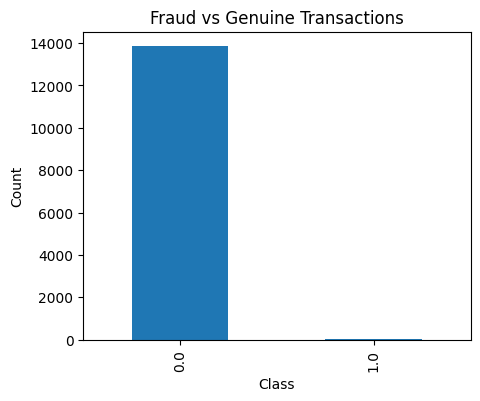

In [33]:
plt.figure(figsize=(5,4))
df["Class"].value_counts().plot(kind="bar")
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

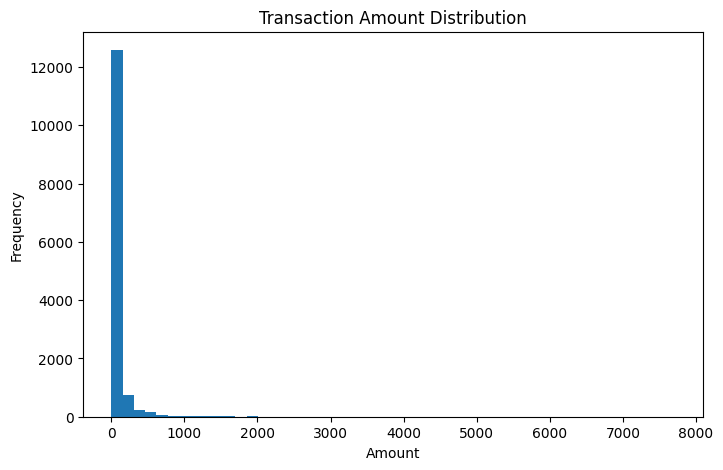

In [34]:
plt.figure(figsize=(8,5))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()


In [35]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("\nX Shape :", X.shape)
print("y Shape :", y.shape)


X Shape : (13900, 30)
y Shape : (13900,)


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])


Training Samples : 11120
Testing Samples : 2780


In [38]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nModel Trained Successfully")


Model Trained Successfully


In [39]:
y_pred = model.predict(X_test)


In [40]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", accuracy)


Accuracy : 0.9992805755395684


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2769
         1.0       1.00      0.82      0.90        11

    accuracy                           1.00      2780
   macro avg       1.00      0.91      0.95      2780
weighted avg       1.00      1.00      1.00      2780



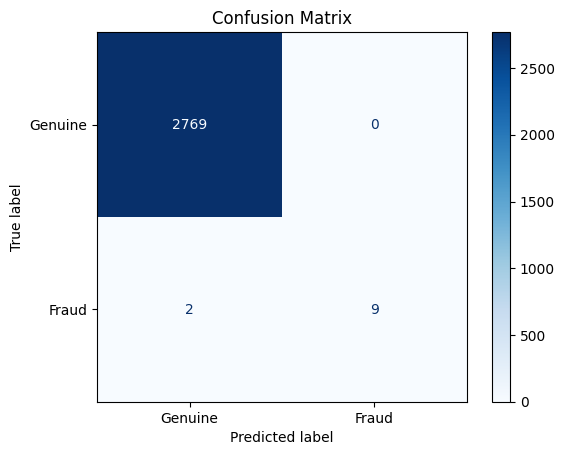

In [42]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine","Fraud"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


Top 10 Important Features
V12       0.146655
V14       0.120679
V17       0.094331
V11       0.092261
V10       0.079973
V4        0.058813
V9        0.055544
V16       0.046014
V26       0.036946
Amount    0.024374
dtype: float64


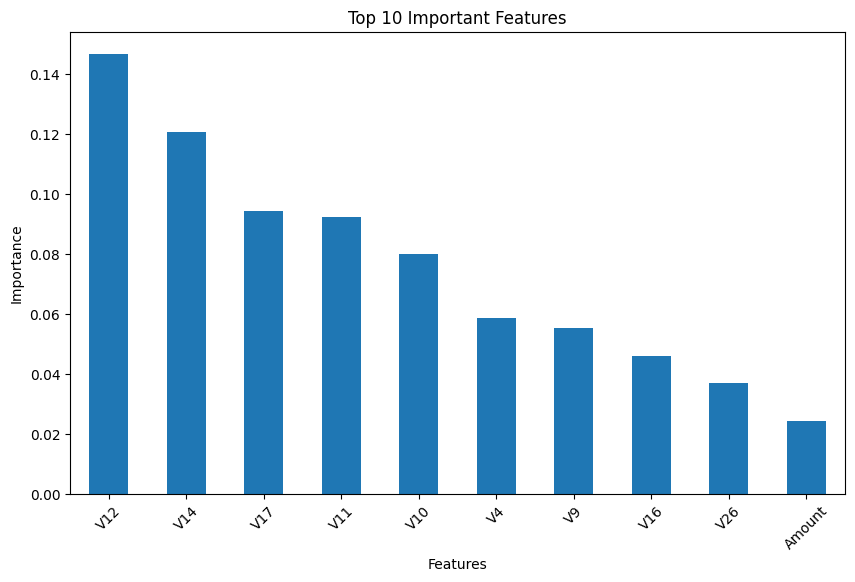

In [43]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features")
print(importance.head(10))

plt.figure(figsize=(10,6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()


In [44]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("\nPrediction : Fraudulent Transaction")
else:
    print("\nPrediction : Genuine Transaction")


Prediction : Genuine Transaction
